# H&M Fashion Recommendation — Data Preparation

## Overview

This notebook prepares the raw H&M dataset for training a Two-Tower neural retrieval model followed by a LightGBM re-ranker. The pipeline outputs processed parquet files, vocabulary mappings, text embeddings, and config files that are consumed directly by the training notebooks.

**Raw data:**
- `transactions_train.csv` — 31,788,324 rows, 5 columns
- `customers.csv` — 1,371,980 rows, 7 columns
- `articles.csv` — 105,542 rows, 25 columns

**After filtering:**
- `transactions_train.csv` — 12,746,999 rows
- `customers.csv` — 96,220 rows
- `articles.csv` — 105,542 rows (unchanged — see ARCHIVED note below)

---

## 1. Customer Filtering (`MIN_TRANSACTIONS = 75`)

**Decision:** Keep only customers with at least 75 transactions.

**Reasoning:** The Two-Tower model learns user preferences from purchase sequences. Customers with very few transactions do not provide enough signal for the sequence encoder (SASRec-style Transformer) to learn a meaningful user embedding. Tested thresholds:

| min_transactions | customers kept |
|---|---|
| 20 | ~439,000 |
| 50 | ~171,000 |
| 75 | **96,220** |
| 100 | ~67,000 |
| 150 | ~36,000 |

75 was chosen as the best balance: retains 96K active customers (rich signal), reduces training data to ~12.7M transactions (feasible on a T4 GPU in 3–4 hours), and eliminates cold-start users who would add noise without contributing learnable patterns.

Both `transactions_df` and `customers_df` are filtered to only include these customers. `articles_df` is left untouched — all 105,542 articles remain (see ARCHIVED section).

---

## 2. transactions_train.csv — Feature Engineering

### 2a. Price → `price_bucket` (q=7)

**Decision:** Equal-frequency binning into 7 buckets using `pd.qcut`.

**Reasoning:** Raw price is a continuous value with 9,111 unique points — too sparse for an embedding lookup. Equal-frequency binning ensures each bucket is equally represented in the training data, avoiding dominance by any one price tier. The number of buckets was chosen by scanning q=6..19 and minimising the Coefficient of Variation (CV = std/mean of bin counts), which measures unevenness. CV scan result:

| q | bins | CV |
|---|---|---|
| 6 | 6 | 0.312 |
| **7** | **7** | **0.290** ← best |
| 8 | 8 | 0.293 |
| 9 | 9 | 0.460 |

q=7 produced the most evenly distributed bins. Note: `duplicates='drop'` handles tied price points (many items share a few spike prices like 0.033881 at ~10% of all transactions).

Final distribution across 7 buckets: 14.4% / 19.9% / 9.1% / 15.3% / 18.1% / 8.9% / 14.3%.

### 2b. `sales_channel_id` → `{1: 0, 2: 1}`

**Decision:** Remap store (1) → 0, online (2) → 1.

**Reasoning:** Binary feature; remapped to 0/1 for cleaner downstream embedding. The model will learn whether online vs. in-store purchasing patterns differ per user.

### 2c. `t_dat` → `sequence_index`

**Decision:** Within each customer, number transactions in chronological order starting from 0 (cumcount after sorting by date).

**Reasoning:** The sequence encoder needs to know the causal order of items a user purchased. Sequence index is the position embedding input. Max sequence index is 1894 (most active user), capped at 512 in the model config since the Transformer attention cost scales quadratically.

### 2d. `t_dat` → `time_delta_bucket` (6 bins)

**Decision:** Bucket the gap in days between consecutive purchases per user into 6 bins: same-day, 1–3 days, 4–14 days, 15–30 days, 31–90 days, 90+ days.

**Reasoning:** The time gap between purchases carries behavioral signal — same-day purchases suggest basket-filling, while multi-month gaps suggest seasonal or event-driven purchases. Continuous day counts are too sparse and noisy for direct embedding. 6 bins were chosen with semantically meaningful thresholds rather than equal-frequency, because the intent is interpretable temporal context. A 7th bin for 180+ days was merged into the 90+ bucket because it held only 0.1% of transactions and adding a near-empty bucket would degrade embedding quality.

First transaction per customer gets `time_delta_days=0` (filled via `.diff().fillna(0)`), mapped to bucket 0 (same-day / no prior purchase).

### 2e. `t_dat` → `season_sin`, `season_cos`

**Decision:** Encode the day of year as a circular sine/cosine pair.

**Reasoning:** Fashion purchases are strongly seasonal — summer dresses peak in spring/early summer, coats in autumn. Day of year is a circular feature (day 365 is adjacent to day 1), so a linear encoding would create a false discontinuity at year boundaries. The sine/cosine encoding correctly captures this circular structure. The pair is projected through a `Linear(2, season_dim)` layer in the model. The raw `day_of_year` and `time_delta_days` columns are dropped after this step.

---

## 3. Article ID Encoding (`article_encoded`, starts from 1)

**Decision:** Map all `article_id` values to integers 1..N, with 0 explicitly reserved as the padding token.

**Reasoning:** The sequence encoder is built on a SASRec-style Transformer that packs user purchase histories into a fixed-length tensor initialized with `np.zeros(MAX_SEQ_LEN)`. Zero means "empty slot / no purchase here." If article indices started from 0, the model would confuse the first article with padding. Starting from 1 keeps the padding sentinel distinct from all real articles.

The vocabulary is built from all 105,542 articles in `articles_df` (the canonical source), sorted lexicographically by `article_id` string. The resulting `article_vocab` dict and its size are used to configure the embedding layer:

```
embedding(article_id_count=105543, article_id_dim=64)
#           ↑ len(article_vocab) + 1, because index 0 is padding
```

This encoding is added to both `articles_df` (for the item tower lookup) and `transactions_df` (for sequence construction).

**ARCHIVED articles:** No special encoding is applied to archived/discontinued articles during data preparation or training. All articles — active and archived — appear in training sequences as-is. The ARCHIVED filter is applied only at inference time: when building the FAISS index of item embeddings, only active articles are included. This means the user tower learns from the full purchase history (realistic), while the retrieval candidates at serving time are constrained to purchasable items (practical).

---

## 4. Customer ID Encoding (`customer_encoded`, starts from 0)

**Decision:** Map all `customer_id` values to integers 0..N-1 using a plain dict lookup.

**Reasoning:** Customer IDs are SHA-256 hashes with no ordinal meaning. The customer embedding matrix has shape `(customer_count, customer_dim)` where index 0 is a valid customer (unlike article_encoded where 0 is padding). There is no sequence-packing with `np.zeros` for customers — each training example has exactly one customer — so starting from 0 is fine and consistent with the standard PyTorch embedding convention.

Unknown customers at inference time fall back to index 0 via `cust_id2idx.get(cid, 0)` (first alphabetical customer, effectively a cold-start fallback).

---

## 5. customers.csv — Cleaning & Feature Engineering

### 5a. `FN`, `Active` → fillna(0)

Binary flags indicating whether a customer opted into H&M's loyalty program (FN) and is currently active. ~54K customers have NaN for both, meaning they never set these preferences. Filling with 0 (opted-out / inactive) is the correct semantic interpretation — unknown = no preference indicated.

### 5b. `club_member_status` → `{ACTIVE: 0, PRE-CREATE: 1, LEFT CLUB: 2, NaN: 3}`

**Reasoning:** 4-class categorical. NaN is assigned its own class (3) rather than being merged with any real status — the model can learn that "unknown membership status" is a distinct behavioral signal from explicitly leaving or never completing registration.

### 5c. `fashion_news_frequency` → `{NONE: 0, Regularly: 1, Monthly: 2, NaN: 3}`

**Reasoning:** Same rationale as club_member_status. NaN gets class 3.

### 5d. `postal_code` — dropped

**Reasoning:** Postal codes in this dataset are cryptographic SHA-256 hashes with no geographic structure — alphabetic sorting or numeric conversion carries no spatial meaning. Including it would only add noise. Dropped entirely.

### 5e. `age` → `age_bucket` (q=10, 11 classes including NaN)

**Decision:** Equal-frequency binning into 10 age buckets. NaN age gets its own class (10).

**Reasoning:** Raw age (integer 16–99) is too sparse for embedding and has 144 missing values. A CV scan over q=4..11 found q=5 optimal (CV=0.048), but 5 buckets lacks semantic granularity — at q=5, each bucket spans ~17 years, conflating teenagers with 30-year-olds. q=10 (CV=0.097, still well-controlled) gives roughly decade-wide bins that align with real fashion taste segments: Gen Z, young adults, early career, mid-career, etc. The 144 NaN customers are assigned bucket 10 (their own class), so the model can learn from missingness patterns rather than imputing a false age.

Final distribution: 10 main buckets each covering 7.99%–11.20% of customers, plus bucket 10 (NaN) at 0.15%.

---

## 6. articles.csv — Cleaning & Feature Engineering

### 6a. Column Selection

From 25 raw columns, kept:
- `article_id` — primary key
- `article_encoded` — integer index for embedding lookup
- `product_type_no`, `graphical_appearance_no`, `colour_group_code`, `index_group_no`, `section_no`, `garment_group_no` — categorical item attributes for the item tower
- `prod_name`, `detail_desc` — text fields for generating text embeddings

Dropped columns are either redundant string labels for the same categoricals (e.g. `product_type_name` alongside `product_type_no`), or higher-granularity codes whose signal is already captured by the retained features.

### 6b. `combined_desc` = `prod_name + ". " + detail_desc`

**Reasoning:** The text encoder (Sentence Transformer) produces a richer embedding when given more context. Concatenating the product name and description gives the model both the item category label and its specific properties in a single string. Missing `detail_desc` values (416 articles) are filled with an empty string, giving just the product name.

### 6c. Categorical LabelEncoding (0..N-1)

`product_type_no`, `graphical_appearance_no`, `colour_group_code`, `index_group_no`, `section_no`, `garment_group_no` are LabelEncoded to contiguous integers 0..N-1.

**Reasoning:** The raw numeric codes from H&M have gaps (e.g. `section_no` values are not 0..56 — they are sparse IDs). LabelEncoding maps them to a dense range, which is required for PyTorch `nn.Embedding` layers (index must be in [0, num_embeddings)).

---

## 7. Text Embeddings (`text_embeddings.npy`)

**Model:** `all-MiniLM-L6-v2` (Sentence Transformers) — produces 384-dimensional embeddings.

**Input:** `combined_desc` for all 105,542 articles, sorted by `article_encoded` (ascending). This ensures row `i` in the embedding matrix corresponds to the article with `article_encoded = i+1` (since encoding starts at 1, row 0 = article_encoded 1).

**`normalize_embeddings=False`:** Embeddings are stored raw (not L2-normalized). Normalization happens inside the item tower at training/inference time, ensuring the text embedding branch participates correctly in the joint projection.

**`art_id2text_idx`:** A dict mapping `article_id` (original H&M integer) → row index in `text_embeddings`. This is the lookup used by the item tower's `compute_item_embeddings()` at inference time:
```python
text_vec = text_embeddings[art_id2text_idx[article_id]]
```
Saved as `art_id2text_idx.pkl`.

---

## 8. Configs (`*_config.pkl`)

All embedding sizes and vocabulary counts are computed dynamically from the processed data — no hardcoded magic numbers. Key design notes:

- `article_id_count = len(article_vocab) + 1` — the +1 is for the padding token at index 0
- `max_seq_len = min(sequence_index.max() + 1, 512)` — capped at 512 for Transformer memory; the actual max is 1895 but sequences are padded/truncated to 512
- `age_bucket_count = age_bucket.max() + 1 = 11` — includes bucket 10 (NaN)
- All other counts follow standard `max() + 1` convention

---

## 9. Temporal Train/Test/Val Split

| Split | Date range | Purpose |
|---|---|---|
| `train_df` | Sep 20, 2018 – Sep 8, 2020 | Two-Tower training |
| `tt_test_df` | Sep 9–15, 2020 | Two-Tower evaluation + LightGBM label window |
| `val_df` | Sep 16–22, 2020 | Final MAP@12 hold-out |

**Reasoning:** Temporal splits are mandatory for recommendation systems — random splits would leak future purchases into training, causing inflated metrics that don't reflect real-world performance. The 7-day windows for test and validation align with the H&M Kaggle competition evaluation protocol (weekly purchase prediction).

## Downloading the dataset from Kaggle and save to Drive

In [ ]:
import kagglehub
kagglehub.login()

In [ ]:
articles_path = kagglehub.competition_download(
    'h-and-m-personalized-fashion-recommendations',
    path='articles.csv'
)

In [ ]:
customers_path = kagglehub.competition_download(
    'h-and-m-personalized-fashion-recommendations',
    path='customers.csv'
)

In [ ]:
transactions_path = kagglehub.competition_download(
    'h-and-m-personalized-fashion-recommendations',
    path='transactions_train.csv'
)

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────
# Set DATASET_FOLDER to the directory that contains (or will contain) the
# raw CSVs and processed parquet files.
#
# Option A — Google Colab + Google Drive:
#   from google.colab import drive
#   drive.mount('/content/drive')
#   ORG_DATASET_FOLDER = '/content/drive/MyDrive/<your_path>/dataset/original'
#   DATASET_FOLDER     = '/content/drive/MyDrive/<your_path>/dataset'
#
# Option B — local / Kaggle notebook:
ORG_DATASET_FOLDER = './dataset/original'    # raw CSVs
DATASET_FOLDER     = './dataset'             # processed parquets + config pickles + text_embeddings.npy

In [ ]:
import os
import shutil

# Copy downloaded CSVs into ORG_DATASET_FOLDER (defined in the config cell below)
downloaded_files = [articles_path, customers_path, transactions_path]
os.makedirs(ORG_DATASET_FOLDER, exist_ok=True)

print('Copying CSVs to dataset folder...')
for file_path in downloaded_files:
    file_name = os.path.basename(file_path)
    destination = os.path.join(ORG_DATASET_FOLDER, file_name)
    shutil.copy2(file_path, destination)
    print(f'  Saved: {file_name}')

print('Done.')

## Load the Dataset


In [ ]:
import numpy as np
import pandas as pd

a_df = pd.read_csv(f'{ORG_DATASET_FOLDER}/articles.csv')
c_df = pd.read_csv(f'{ORG_DATASET_FOLDER}/customers.csv')
t_df = pd.read_csv(f'{ORG_DATASET_FOLDER}/transactions_train.csv')

articles_df     = a_df.copy()
customers_df    = c_df.copy()
transactions_df = t_df.copy()

print('Data loaded successfully!')
print(f'  articles:     {articles_df.shape}')
print(f'  customers:    {customers_df.shape}')
print(f'  transactions: {transactions_df.shape}')

Data loaded from Drive!


In [ ]:
print(transactions_df.shape)
print(customers_df.shape)
print(articles_df.shape)

(31788324, 5)
(1371980, 7)
(105542, 25)


## Data Split

In [ ]:
# deciding what is the best minimum transactions threshold
for min_t in [20, 30, 50, 75, 100, 150, 200]:
    n = (transactions_df['customer_id'].value_counts() >= min_t).sum()
    print(f"min_transactions={min_t:3d} → {n:,} customers")

min_transactions= 20 → 439,261 customers
min_transactions= 30 → 312,187 customers
min_transactions= 50 → 175,792 customers
min_transactions= 75 → 96,220 customers
min_transactions=100 → 57,266 customers
min_transactions=150 → 23,834 customers
min_transactions=200 → 11,476 customers


In [ ]:
MIN_TRANSACTIONS = 75

# keep customers who has at least 75 transactions
customer_counts = transactions_df['customer_id'].value_counts()
active_customers = customer_counts[customer_counts >= MIN_TRANSACTIONS].index
transactions_df = transactions_df[transactions_df['customer_id'].isin(active_customers)].copy()
customers_df = customers_df[customers_df['customer_id'].isin(active_customers)].copy()

del customer_counts

In [ ]:
print(transactions_df.shape)
print(customers_df.shape)
print(articles_df.shape)

(12746999, 5)
(96220, 7)
(105542, 25)


## Data Analysis & Visualization

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# count the number of transactions for each customer
transaction_counts = transactions_df['customer_id'].value_counts()

print("Top 10 MOST Buying Users:")
print(transaction_counts.head(10))
print()
print("Top 10 LEAST Buying Users (within your Top 10k):")
print(transaction_counts.tail(10))

Top 10 MOST Buying Users:
customer_id
be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee985513d9e8e53c6d91b    1895
b4db5e5259234574edfff958e170fe3a5e13b6f146752ca066abca3c156acc71    1441
49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05b50a4cd88e34d0748f    1364
a65f77281a528bf5c1e9f270141d601d116e1df33bf9df512f495ee06647a9cc    1361
cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed6012e7e5bea016b4d6    1237
55d15396193dfd45836af3a6269a079efea339e875eff42cc0c228b002548a9d    1208
c140410d72a41ee5e2e3ba3d7f5a860f337f1b5e41c27cf9bda5517c8774f8fa    1170
8df45859ccd71ef1e48e2ee9d1c65d5728c31c46ae957d659fa4e5c3af6cc076    1169
03d0011487606c37c1b1ed147fc72f285a50c05f00b9712e0fc3da400c864296    1157
6cc121e5cc202d2bf344ffe795002bdbf87178054bcda2e57161f0ef810a4b55    1143
Name: count, dtype: int64

Top 10 LEAST Buying Users (within your Top 10k):
customer_id
acc03ece62cad0188fa66f942ff738789b7a85568c24349cdf5f8cd7096b1e19    75
475b119ef98d551c4f5b58fc364c5297300c66d30c9dfec39a8b704d98adfeb3    75
d7

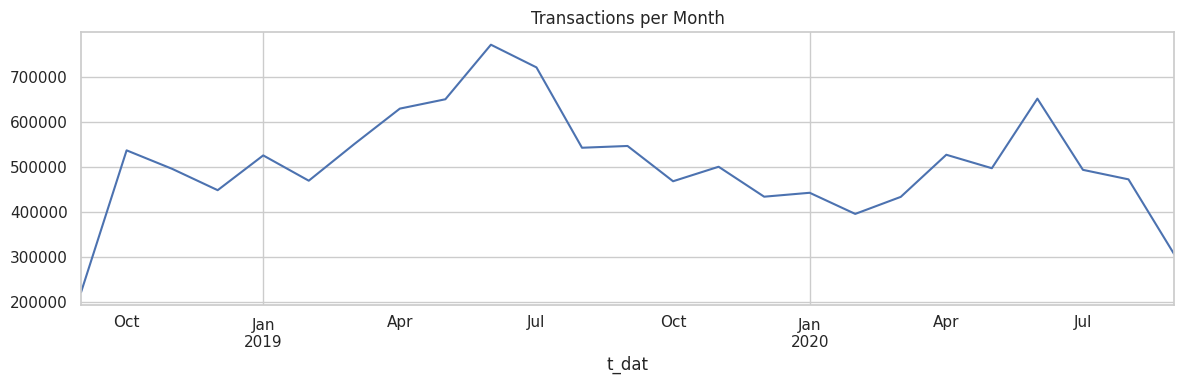

In [ ]:

# Chart 1 — Transactions over time (line chart)
transactions_df['t_dat'] = pd.to_datetime(transactions_df['t_dat'])
transactions_df.groupby(transactions_df['t_dat'].dt.to_period('M')).size().plot(
    kind='line', figsize=(12,4), title='Transactions per Month')
plt.tight_layout(); plt.savefig('transactions_over_time.png')


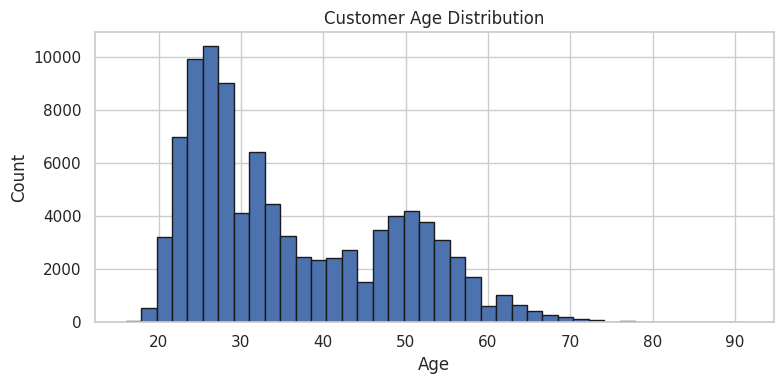

In [ ]:
# Chart 2 — Customer age distribution (histogram)
customers_df['age'].dropna().hist(bins=40, figsize=(8,4), edgecolor='k')
plt.title('Customer Age Distribution'); plt.xlabel('Age'); plt.ylabel('Count')
plt.tight_layout(); plt.savefig('age_distribution.png')

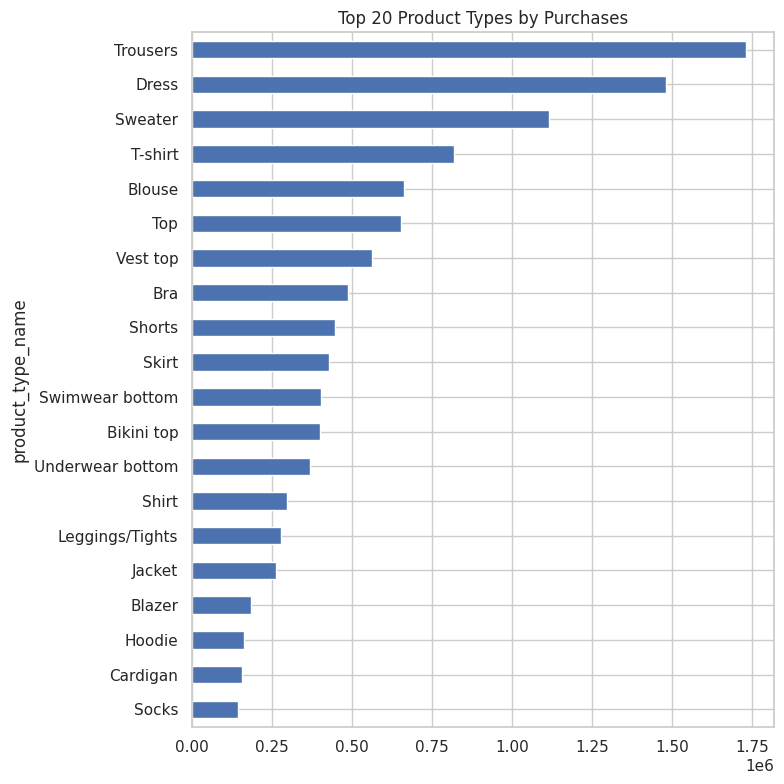

In [ ]:
# Chart 3 — Top 20 product types by transaction volume (horizontal bar chart)
tx_art = transactions_df.merge(articles_df[['article_id','product_type_name']], on='article_id')
tx_art['product_type_name'].value_counts().head(20).sort_values().plot(
    kind='barh', figsize=(8,8), title='Top 20 Product Types by Purchases')
plt.tight_layout(); plt.savefig('product_type_dist.png')

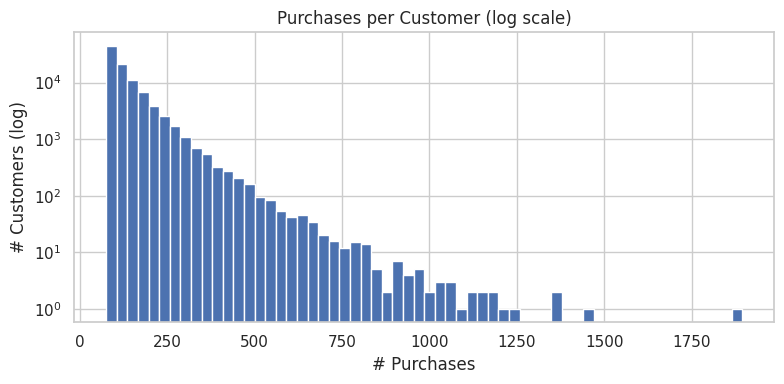

In [ ]:
# Chart 4 — Purchases per customer distribution (log-scale histogram)
transactions_df.groupby('customer_id').size().hist(bins=60, log=True, figsize=(8,4))
plt.title('Purchases per Customer (log scale)'); plt.xlabel('# Purchases'); plt.ylabel('# Customers (log)')
plt.tight_layout(); plt.savefig('purchases_per_user.png')

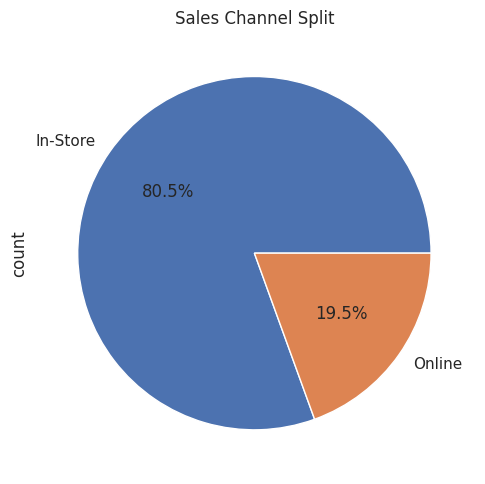

In [ ]:
# Chart 5 — Sales channel split (pie chart)
transactions_df['sales_channel_id'].value_counts().plot(
    kind='pie', labels=['In-Store','Online'],
    autopct='%1.1f%%', figsize=(5,5), title='Sales Channel Split')
plt.tight_layout(); plt.savefig('channel_split.png')

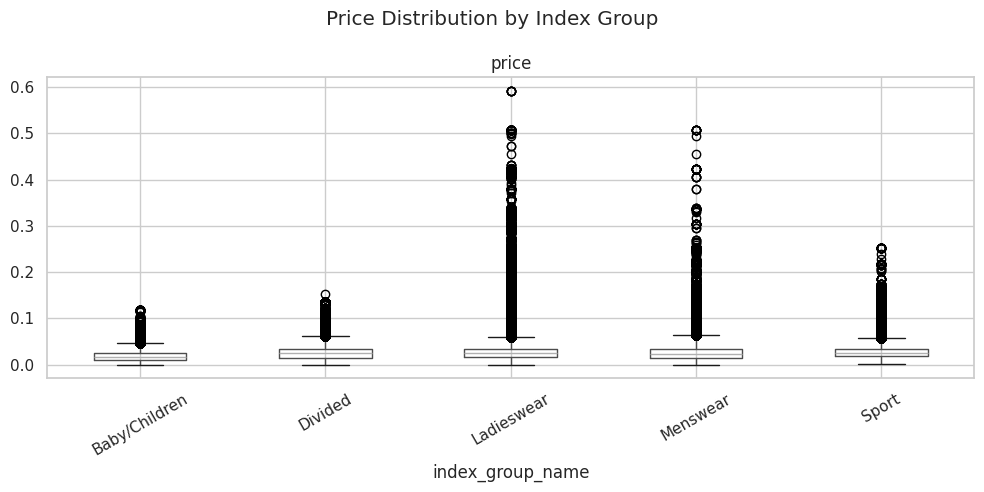

In [ ]:
# Chart 6 — Price vs product type (box plot)
tx_art = transactions_df.merge(articles_df[['article_id','index_group_name']], on='article_id')
tx_art.boxplot(column='price', by='index_group_name', figsize=(10,5), rot=30)
plt.suptitle('Price Distribution by Index Group')
plt.tight_layout(); plt.savefig('price_by_group.png')

/tmp/ipykernel_1109/4023723971.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = tx_full.groupby(['age_group','index_group_name']).size().unstack(fill_value=0)


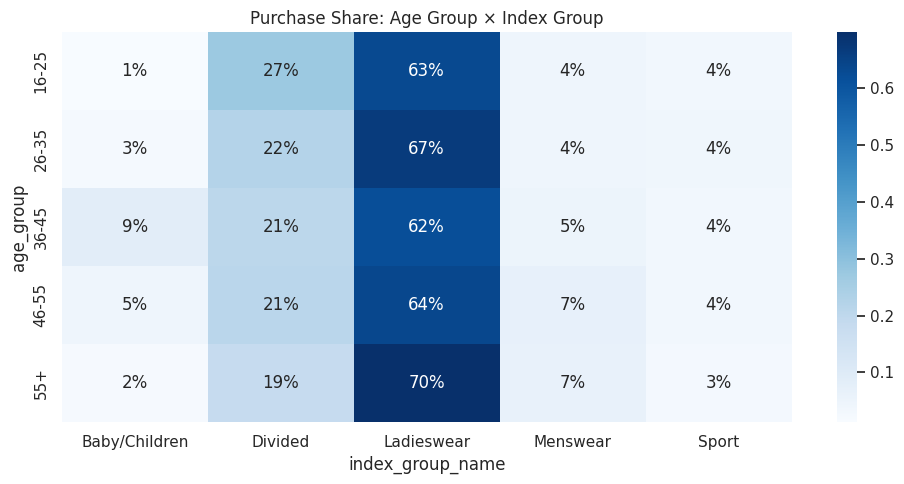

In [ ]:
# Chart 7 — Purchase heatmap: age bucket × index_group (heatmap)

import seaborn as sns
tx_full = transactions_df.merge(articles_df[['article_id','index_group_name']], on='article_id') \
                         .merge(customers_df[['customer_id','age']], on='customer_id')
tx_full['age_group'] = pd.cut(tx_full['age'], bins=[15,25,35,45,55,99],
                               labels=['16-25','26-35','36-45','46-55','55+'])
pivot = tx_full.groupby(['age_group','index_group_name']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
plt.figure(figsize=(10,5))
sns.heatmap(pivot_pct, annot=True, fmt='.0%', cmap='Blues')
plt.title('Purchase Share: Age Group × Index Group')
plt.tight_layout(); plt.savefig('age_category_heatmap.png')

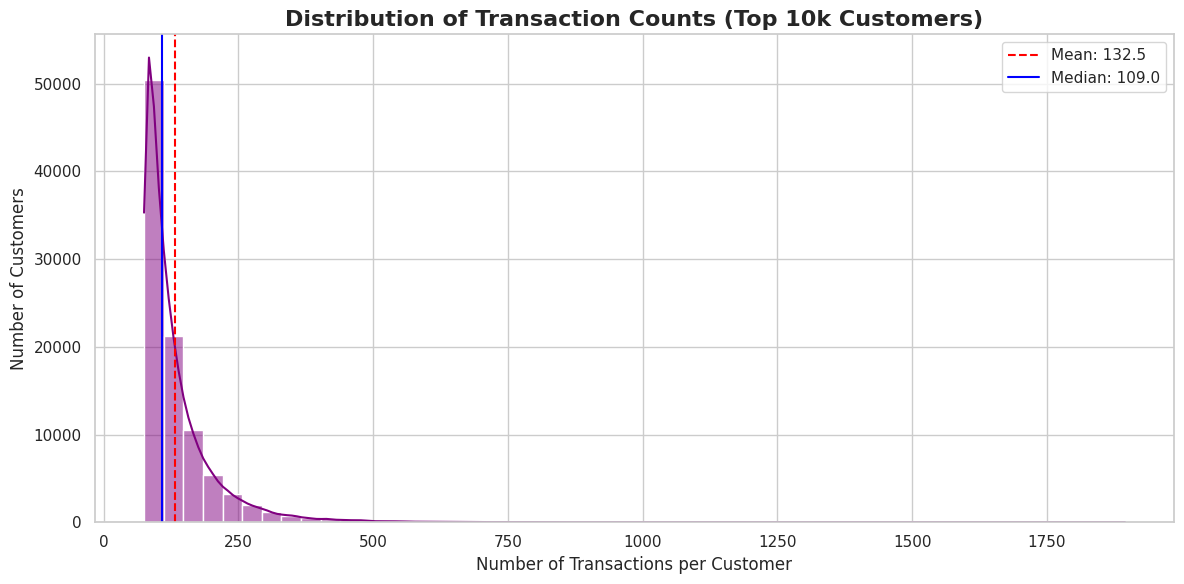

In [ ]:
# Chart 9 — Transaction count distribution (histogram)
import seaborn as sns

tx_counts = transactions_df['customer_id'].value_counts()
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(tx_counts, bins=50, color='purple', kde=True)
plt.title('Distribution of Transaction Counts (Top 10k Customers)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Transactions per Customer', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.axvline(tx_counts.mean(),   color='red',  linestyle='--', label=f'Mean: {tx_counts.mean():.1f}')
plt.axvline(tx_counts.median(), color='blue', linestyle='-',  label=f'Median: {tx_counts.median():.1f}')
plt.legend()
plt.tight_layout(); plt.savefig('user_count_dist.png')

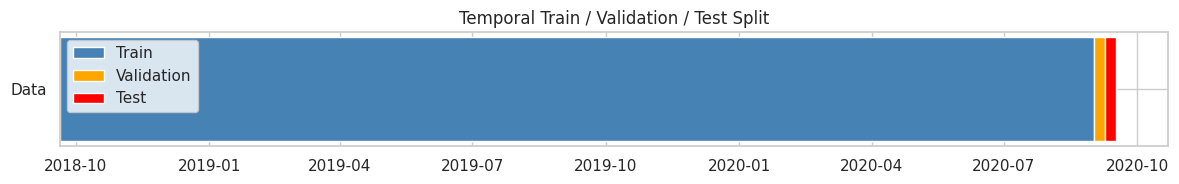

In [ ]:
# Chart 10 — Temporal split visualization
fig, ax = plt.subplots(figsize=(12, 2))
ax.barh(['Data'], [pd.Timestamp('2020-09-01') - pd.Timestamp('2018-09-20')], left=pd.Timestamp('2018-09-20'), color='steelblue', label='Train')
ax.barh(['Data'], [pd.Timedelta('8d')], left=pd.Timestamp('2020-09-01'), color='orange', label='Validation')
ax.barh(['Data'], [pd.Timedelta('7d')], left=pd.Timestamp('2020-09-09'), color='red', label='Test')
ax.legend(); ax.set_title('Temporal Train / Validation / Test Split')
plt.tight_layout(); plt.savefig('temporal_split.png')

## Data Cleaning

### transactions_train.csv

In [ ]:
print(f"Transactions NAN:\n{transactions_df.isna().sum()}")
print()
transactions_df.head()

Transactions NAN:
t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64



,t_dat,customer_id,article_id,price,sales_channel_id
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2
5,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687001,0.016932,2
6,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221001,0.020322,2


In [ ]:
# show 50 most frequent price points
price_popularity = transactions_df['price'].value_counts().reset_index()
price_popularity.columns = ['price', 'transaction_count']

total_transactions = len(transactions_df)
price_popularity['percentage'] = (price_popularity['transaction_count'] / total_transactions) * 100

print("Top 50 Most Frequent Price Points:")
print(price_popularity.head(50).to_string(index=False))

Top 50 Most Frequent Price Points:
   price  transaction_count  percentage
0.033881            1324102   10.387559
0.025407            1195985    9.382483
0.016932            1184158    9.289700
0.050831             614313    4.819276
0.042356             599640    4.704166
0.013542             545257    4.277532
0.022017             490588    3.848655
0.030492             442118    3.468409
0.008458             354792    2.783337
0.067780             266793    2.092987
0.015237             248564    1.949981
0.010153             238649    1.872198
0.027102             211922    1.662525
0.020322             200580    1.573547
0.011847             197463    1.549094
0.059305             171255    1.343493
0.006763             157940    1.239037
0.084729             104874    0.822735
0.040661              95836    0.751832
0.005068              95140    0.746372
0.022864              84746    0.664831
0.028797              69950    0.548757
0.018627              57234    0.449000
0.024

In [ ]:
# deciding on the best bucket size number for "price"

best_q, best_cv = None, float('inf')
for q in range(6, 20):
    b = pd.qcut(transactions_df['price'], q=q, labels=False, duplicates='drop')
    counts = b.value_counts()
    cv = counts.std() / counts.mean()
    n_bins = b.nunique()
    print(f"q={q:2d} → {n_bins} bins | CV={cv:.3f}")
    if cv < best_cv:
        best_cv, best_q = cv, q

# CV (coefficient of variation = std/mean of bin counts) measures unevenness — lower is better
print(f"\nBest q={best_q} (CV={best_cv:.3f})")

q= 6 → 6 bins | CV=0.312
q= 7 → 7 bins | CV=0.290
q= 8 → 8 bins | CV=0.293
q= 9 → 9 bins | CV=0.460
q=10 → 10 bins | CV=0.446
q=11 → 11 bins | CV=0.362
q=12 → 11 bins | CV=0.458
q=13 → 13 bins | CV=0.406
q=14 → 14 bins | CV=0.519
q=15 → 13 bins | CV=0.539
q=16 → 14 bins | CV=0.404
q=17 → 16 bins | CV=0.518
q=18 → 15 bins | CV=0.533
q=19 → 16 bins | CV=0.618

Best q=7 (CV=0.290)


In [ ]:
# 1. create bucket ranges for "price" columns
transactions_df['price_bucket'] = pd.qcut(transactions_df['price'], q=7, labels=False, duplicates='drop')
ranges = transactions_df.groupby('price_bucket')['price'].agg(['min', 'max', 'count']).reset_index()
ranges['pct'] = (ranges['count'] / len(transactions_df) * 100).round(1)

print(f"Ranges for q={7}:")
print(ranges.to_string(index=False))

Ranges for q=7:
 price_bucket      min      max   count  pct
            0 0.000034 0.012186 1840507 14.4
            1 0.012203 0.016932 2536542 19.9
            2 0.016949 0.022017 1162392  9.1
            3 0.022034 0.027102 1947903 15.3
            4 0.027119 0.033881 2310047 18.1
            5 0.033898 0.045746 1131887  8.9
            6 0.045763 0.591525 1817721 14.3


In [ ]:
# 2. sales_channel_id: 1 -> 0 (store), 2 -> 1 (online)
transactions_df['sales_channel_id'] = transactions_df['sales_channel_id'].map({1: 0, 2: 1})

In [ ]:
# 3. t_dat: derive causal order (sequence_index) of transactions for each user
transactions_df['t_dat'] = pd.to_datetime(transactions_df['t_dat'])
transactions_df = transactions_df.sort_values(['customer_id', 't_dat'])
transactions_df['sequence_index'] = transactions_df.groupby('customer_id').cumcount()
print(f"\nMax sequence_index: {transactions_df['sequence_index'].max()}")


Max sequence_index: 1894


In [ ]:
# 4. t_dat: derive time delta day buckets (gap between each transaction) for each user
transactions_df['time_delta_days'] = transactions_df.groupby('customer_id')['t_dat'].diff().dt.days.fillna(0)
bins = [-np.inf, 0, 3, 14, 30, 90, np.inf]
transactions_df['time_delta_bucket'] = pd.cut(transactions_df['time_delta_days'], bins=bins, labels=False).astype(int)

In [ ]:
# 5. t_dat: derive day of year [1-365] for each user
# ['season_sin', 'season_cos'] vector correctly represents the order (Position Encoding)
transactions_df['day_of_year'] = transactions_df['t_dat'].dt.dayofyear
transactions_df['season_sin'] = np.sin(2 * np.pi * transactions_df['day_of_year'] / 365.25)
transactions_df['season_cos'] = np.cos(2 * np.pi * transactions_df['day_of_year'] / 365.25)
transactions_df = transactions_df.drop(columns=['time_delta_days', 'day_of_year'])

In [ ]:
# 6. convert article_id hex string to integers from 1...N (0 is for PAD token) for embedding lookup

# build hex string to number vocab from articles_df — canonical source
all_article_ids = sorted([str(x) for x in articles_df['article_id'].unique()])
article_vocab = {aid: i + 1 for i, aid in enumerate(all_article_ids)}

# add encoded article_id to articles.csv
articles_df['article_encoded']     = articles_df['article_id'].astype(str).map(article_vocab).astype(int)

# add encoded article_id to transactions.csv
transactions_df['article_encoded'] = transactions_df['article_id'].astype(str).map(article_vocab).astype(int)

# article_vocab ==> hex_string : i+1, 0 < i < N
print(f"Vocab size: {len(article_vocab)} (0 reserved for padding)")
print(f"transactions NaN encoded: {transactions_df['article_encoded'].isna().sum()}")  # must be 0

Vocab size: 105542 (0 reserved for padding)
transactions NaN encoded: 0


In [ ]:
# 7. convert customer_id hex string to integers from 1...N

# build hex string to number vocab from customers_df — canonical source
all_customer_ids = sorted([str(x) for x in customers_df['customer_id'].unique()])
cust_id2idx = {cid: i for i, cid in enumerate(all_customer_ids)}

# add encoded customer_id to customers.csv
customers_df['customer_encoded']     = customers_df['customer_id'].astype(str).map(cust_id2idx).astype(int)

# add encoded customer_id to transactions.csv
transactions_df['customer_encoded']  = transactions_df['customer_id'].astype(str).map(cust_id2idx).astype(int)

In [ ]:
# print unique count & values for each column
for col in transactions_df.columns:
    n_unique = transactions_df[col].nunique()
    n_nan    = transactions_df[col].isna().sum()
    vals     = transactions_df[col].unique()
    if n_unique < 20:
        print(f"'{col}' | Unique: {n_unique} | NaN: {n_nan} | Values: {sorted(vals.tolist())}")
    else:
        print(f"'{col}' | Unique: {n_unique} | NaN: {n_nan}")

't_dat' | Unique: 734 | NaN: 0
'customer_id' | Unique: 96220 | NaN: 0
'article_id' | Unique: 99480 | NaN: 0
'price' | Unique: 9111 | NaN: 0
'sales_channel_id' | Unique: 2 | NaN: 0 | Values: [0, 1]
'price_bucket' | Unique: 7 | NaN: 0 | Values: [0, 1, 2, 3, 4, 5, 6]
'sequence_index' | Unique: 1895 | NaN: 0
'time_delta_bucket' | Unique: 6 | NaN: 0 | Values: [0, 1, 2, 3, 4, 5]
'season_sin' | Unique: 365 | NaN: 0
'season_cos' | Unique: 365 | NaN: 0
'article_encoded' | Unique: 99480 | NaN: 0
'customer_encoded' | Unique: 96220 | NaN: 0


In [ ]:
print(f"Transactions NAN:\n{transactions_df.isna().sum()}")
print()
print(transactions_df.shape)
print()
transactions_df.head()

Transactions NAN:
t_dat                0
customer_id          0
article_id           0
price                0
sales_channel_id     0
price_bucket         0
sequence_index       0
time_delta_bucket    0
season_sin           0
season_cos           0
article_encoded      0
customer_encoded     0
dtype: int64

(12746999, 12)



,t_dat,customer_id,article_id,price,sales_channel_id,price_bucket,sequence_index,time_delta_bucket,season_sin,season_cos,article_encoded,customer_encoded
48399,2018-09-21,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,583558001,0.067780,1,6,0,0,-0.985424,-0.170118,19334,0
48400,2018-09-21,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,639677008,0.025407,1,3,1,0,-0.985424,-0.170118,33749,0
48401,2018-09-21,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,640244003,0.033881,1,4,2,0,-0.985424,-0.170118,33992,0
211791,2018-09-25,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,521269001,0.033881,1,4,3,2,-0.994788,-0.101962,8217,0
211792,2018-09-25,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,666448006,0.025407,1,3,4,0,-0.994788,-0.101962,41025,0


### customers.csv

In [ ]:
print(f"Customers \t\t\t NAN:\n{customers_df.isna().sum()}")
print()
customers_df.head()

Customers 			 NAN:
customer_id                   0
FN                        51716
Active                    52198
club_member_status          144
fashion_news_frequency      104
age                         144
postal_code                   0
customer_encoded              0
dtype: int64



,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code,customer_encoded
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...,0
7,00007d2de826758b65a93dd24ce629ed66842531df6699...,1.0,1.0,ACTIVE,Regularly,32.0,8d6f45050876d059c830a0fe63f1a4c022de279bb68ce3...,1
13,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,1.0,1.0,ACTIVE,Regularly,56.0,b31984b20a8c478de38eaf113c581ff64e63c4242e607b...,2
21,0000f1c71aafe5963c3d195cf273f7bfd50bbf17761c91...,1.0,1.0,ACTIVE,Regularly,30.0,7c902dca60ee0bd0f9030eefd445d11146e8d24835738a...,3
38,0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...,1.0,1.0,ACTIVE,Regularly,44.0,930b19ae7db8abb5a27f4da10217755a7305b4c452f5e0...,4


In [ ]:
# 1. fillna in 'FN' & 'Active' columns with 0.0
customers_df['FN']     = customers_df['FN'].fillna(0).astype(np.float32)
customers_df['Active'] = customers_df['Active'].fillna(0).astype(np.float32)

# 2. convert club_member_status categorical values to integer [ACTIVE=0, PRE-CREATE=1, LEFT CLUB=2, NaN=3]
club_map = {'ACTIVE': 0, 'PRE-CREATE': 1, 'LEFT CLUB': 2}
customers_df['club_member_status'] = (
    customers_df['club_member_status'].map(lambda x: club_map.get(str(x), 3)).astype(int)
)

# 3. convert fashion_news_frequency categorical values to integer [NONE=0, Regularly=1, Monthly=2, NaN=3]
news_map = {'NONE': 0, 'Regularly': 1, 'Monthly': 2}
customers_df['fashion_news_frequency'] = (
    customers_df['fashion_news_frequency'].map(lambda x: news_map.get(str(x), 3)).astype(int)
)

# 4. drop postal_code (cryptographically hashed — no geographic signal)
customers_df = customers_df.drop(['postal_code'], axis=1)

In [ ]:
best_q, best_cv = None, float('inf')
for q in range(4, 12):
    b = pd.qcut(customers_df['age'].dropna(), q=q, duplicates='drop', labels=False)
    counts = b.value_counts()
    cv = counts.std() / counts.mean()
    print(f"q={q} → {b.nunique()} bins | CV={cv:.3f}")
    if cv < best_cv:
        best_cv, best_q = cv, q

# CV (coefficient of variation = std/mean of bin counts) measures unevenness — lower is better
print(f"\nBest q={best_q} (CV={best_cv:.3f})")

q=4 → 4 bins | CV=0.067
q=5 → 5 bins | CV=0.048
q=6 → 6 bins | CV=0.159
q=7 → 7 bins | CV=0.125
q=8 → 8 bins | CV=0.160
q=9 → 9 bins | CV=0.186
q=10 → 10 bins | CV=0.097
q=11 → 11 bins | CV=0.190

Best q=5 (CV=0.048)


In [ ]:
# 5. split age into 10 buckets, 10 was chosen because q=5 was too small for the distribution
customers_df['age_bucket'] = pd.qcut(customers_df['age'], q=10, labels=False, duplicates='drop')
customers_df['age_bucket'] = customers_df['age_bucket'].fillna(10).astype(int)

# drop old "age" column
customers_df = customers_df.drop(['age'], axis=1)

# how much of total dataset does each bucket contain
age_distribution = customers_df['age_bucket'].value_counts().sort_index()
age_stats = pd.DataFrame({
    'count': age_distribution,
    'percentage': (age_distribution / len(customers_df) * 100).round(2)
})
print(age_stats)

            count  percentage
age_bucket                   
0           10772       11.20
1            9918       10.31
2           10407       10.82
3            9009        9.36
4           10549       10.96
5            7684        7.99
6            9993       10.39
7            9010        9.36
8            9591        9.97
9            9143        9.50
10            144        0.15


In [ ]:
# print unique count & values for each column
for col in customers_df.columns:
    n_unique = customers_df[col].nunique()
    n_nan    = customers_df[col].isna().sum()
    vals     = customers_df[col].unique()
    if n_unique < 20:
        print(f"'{col}' | Unique: {n_unique} | NaN: {n_nan} | Values: {sorted(vals.tolist())}")
    else:
        print(f"'{col}' | Unique: {n_unique} | NaN: {n_nan}")

'customer_id' | Unique: 96220 | NaN: 0
'FN' | Unique: 2 | NaN: 0 | Values: [0.0, 1.0]
'Active' | Unique: 2 | NaN: 0 | Values: [0.0, 1.0]
'club_member_status' | Unique: 4 | NaN: 0 | Values: [0, 1, 2, 3]
'fashion_news_frequency' | Unique: 4 | NaN: 0 | Values: [0, 1, 2, 3]
'customer_encoded' | Unique: 96220 | NaN: 0
'age_bucket' | Unique: 11 | NaN: 0 | Values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
print(f"Customers \t\t\t NAN:\n{customers_df.isna().sum()}")
print()
print(customers_df.shape)
print()
customers_df.head()

Customers 			 NAN:
customer_id               0
FN                        0
Active                    0
club_member_status        0
fashion_news_frequency    0
customer_encoded          0
age_bucket                0
dtype: int64

(96220, 7)



,customer_id,FN,Active,club_member_status,fashion_news_frequency,customer_encoded,age_bucket
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0.0,0.0,0,0,0,1
7,00007d2de826758b65a93dd24ce629ed66842531df6699...,1.0,1.0,0,1,1,4
13,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,1.0,1.0,0,1,2,9
21,0000f1c71aafe5963c3d195cf273f7bfd50bbf17761c91...,1.0,1.0,0,1,3,4
38,0001d44dbe7f6c4b35200abdb052c77a87596fe1bdcc37...,1.0,1.0,0,1,4,6


### articles.csv

In [ ]:
print(f"Articles NAN:\n{articles_df.isna().sum()}")
print()
articles_df.head()

Articles NAN:
article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
article_encoded                   0
dtype: int64



,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc,article_encoded
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,1
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,2
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,3
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",4
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",5


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Keep only 9 columns and drop all others
articles_df = articles_df[['article_id', 'article_encoded', 'product_type_no',
                           'graphical_appearance_no', 'colour_group_code', 'index_group_no',
                           'section_no', 'garment_group_no', 'prod_name', 'detail_desc']].copy()

# 2. Create combined_desc column = "{prod_name}. {detail_desc}"
articles_df['combined_desc'] = (
    articles_df['prod_name'].astype(str) + '. ' +
    articles_df['detail_desc'].fillna('').astype(str)
).str.strip('. ')
articles_df = articles_df.drop(['prod_name', 'detail_desc'], axis=1)

# 3. LabelEncode all categorical columns so values are contiguous 1...N
art_label_encoders = {}
for col in ['product_type_no', 'graphical_appearance_no', 'colour_group_code',
            'index_group_no', 'section_no', 'garment_group_no']:
    le = LabelEncoder()
    articles_df[col] = le.fit_transform(articles_df[col].astype(str))
    art_label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} classes → 0..{len(le.classes_)-1}")


product_type_no: 132 classes → 0..131
graphical_appearance_no: 30 classes → 0..29
colour_group_code: 50 classes → 0..49
index_group_no: 5 classes → 0..4
section_no: 57 classes → 0..56
garment_group_no: 21 classes → 0..20


In [ ]:
# print unique count & values for each column
for col in articles_df.columns:
    n_unique = articles_df[col].nunique()
    n_nan    = articles_df[col].isna().sum()
    vals     = articles_df[col].unique()
    if n_unique < 20:
        print(f"'{col}' | Unique: {n_unique} | NaN: {n_nan} | Values: {sorted(vals.tolist())}")
    else:
        print(f"'{col}' | Unique: {n_unique} | NaN: {n_nan}")

'article_id' | Unique: 105542 | NaN: 0
'article_encoded' | Unique: 105542 | NaN: 0
'product_type_no' | Unique: 132 | NaN: 0
'graphical_appearance_no' | Unique: 30 | NaN: 0
'colour_group_code' | Unique: 50 | NaN: 0
'index_group_no' | Unique: 5 | NaN: 0 | Values: [0, 1, 2, 3, 4]
'section_no' | Unique: 57 | NaN: 0
'garment_group_no' | Unique: 21 | NaN: 0
'combined_desc' | Unique: 49502 | NaN: 0


In [ ]:
print(f"Articles \t\t\t NAN:\n{articles_df.isna().sum()}")
print()
print(articles_df.shape)
print()
articles_df.head()

Articles 			 NAN:
article_id                 0
article_encoded            0
product_type_no            0
graphical_appearance_no    0
colour_group_code          0
index_group_no             0
section_no                 0
garment_group_no           0
combined_desc              0
dtype: int64

(105542, 9)



,article_id,article_encoded,product_type_no,graphical_appearance_no,colour_group_code,index_group_no,section_no,garment_group_no,combined_desc
0,108775015,1,12,16,45,0,3,1,Strap top. Jersey top with narrow shoulder straps
1,108775044,2,12,16,2,0,3,1,Strap top. Jersey top with narrow shoulder straps
2,108775051,3,12,17,3,0,3,1,Strap top (1). Jersey top with narrow shoulder...
3,110065001,4,54,16,45,0,42,14,OP T-shirt (Idro). Microfibre T-shirt bra with...
4,110065002,5,54,16,2,0,42,14,OP T-shirt (Idro). Microfibre T-shirt bra with...


In [ ]:
# generate and store text embeddings for "combined_desc" textual column using 'all-MiniLM-L6-v2' model
import os
from sentence_transformers import SentenceTransformer

TEXT_EMB_CACHE = os.path.join(DATASET_FOLDER, 'text_embeddings.npy')

if os.path.exists(TEXT_EMB_CACHE):
    print(f"Loading cached text embeddings from Drive...")
    text_embeddings = np.load(TEXT_EMB_CACHE)
else:
    print("Computing text embeddings (~2 min for 105K articles)...")
    smodel = SentenceTransformer('all-MiniLM-L6-v2')

    articles_ordered = articles_df.sort_values('article_encoded').reset_index(drop=True)
    texts = articles_ordered['combined_desc'].fillna('').tolist()

    text_embeddings = smodel.encode(
        texts, batch_size=256, show_progress_bar=True,
        normalize_embeddings=False, convert_to_numpy=True
    ).astype(np.float32)

    np.save(TEXT_EMB_CACHE, text_embeddings)
    print(f"Saved to Drive: {TEXT_EMB_CACHE}")

print(f"Text embeddings shape: {text_embeddings.shape}")  # (105542, 384)

In [ ]:
import pickle

# configurations
transactions_config = {
    "article_id_count":   len(article_vocab) + 1,
    "article_id_dim":     64,
    "price_bucket_count": int(transactions_df["price_bucket"].max()) + 1,
    "price_bucket_dim":   8,
    "max_seq_len":        min(int(transactions_df['sequence_index'].max()) + 1, 512),
    "time_delta_count":   int(transactions_df["time_delta_bucket"].max()) + 1,
    "time_delta_dim":     4,
    "season_dim":         8,   # [sin, cos] → Linear(2, 8)
}

customers_config = {
    "customer_count":     len(cust_id2idx),
    "customer_dim":       64,
    "club_member_count":  4,      # active, pre-create, left club, nan
    "club_member_dim":    8,
    "fashion_news_count": 4,      # none, regularyly, monthly, nan
    "fashion_news_dim":   8,
    "age_bucket_count":   int(customers_df["age_bucket"].max()) + 1,
    "age_bucket_dim":     8,
}

articles_config = {
    "product_type_count":  len(art_label_encoders['product_type_no'].classes_),
    "product_type_dim":    16,

    "appearance_count":    len(art_label_encoders['graphical_appearance_no'].classes_),
    "appearance_dim":      8,

    "colour_count":        len(art_label_encoders['colour_group_code'].classes_),
    "colour_dim":          16,

    "index_group_count":   len(art_label_encoders['index_group_no'].classes_),
    "index_group_dim":     8,

    "section_count":       len(art_label_encoders['section_no'].classes_),
    "section_dim":         16,

    "garment_group_count": len(art_label_encoders['garment_group_no'].classes_),
    "garment_group_dim":   8
}

# save configs
with open(f'{DATASET_FOLDER}/transactions_config.pkl', 'wb') as f:
  pickle.dump(transactions_config, f)

with open(f'{DATASET_FOLDER}/customers_config.pkl', 'wb') as f:
  pickle.dump(customers_config, f)

with open(f'{DATASET_FOLDER}/articles_config.pkl', 'wb') as f:
  pickle.dump(articles_config, f)


In [ ]:
# train, test, validation splits
SPLIT_TT_END  = pd.Timestamp('2020-09-08')
SPLIT_LGB_END = pd.Timestamp('2020-09-15')
SPLIT_VAL_END = pd.Timestamp('2020-09-22')

# Two-Tower trains on all history up to Sep 8 (H&M data starts 2018-09-20)
train_df = transactions_df[transactions_df['t_dat'] <= SPLIT_TT_END].copy()

# Two-Tower test + future LGB label window: Sep 9–15
tt_test_df = transactions_df[(transactions_df['t_dat'] > SPLIT_TT_END) & (transactions_df['t_dat'] <= SPLIT_LGB_END)].copy()

# Final hold-out: Sep 16–22  (used in Section 3 for MAP@12)
val_df = transactions_df[(transactions_df['t_dat'] > SPLIT_LGB_END) & (transactions_df['t_dat'] <= SPLIT_VAL_END)].copy()

print(f"train_df:     {len(train_df):,} rows | {train_df['customer_id'].nunique():,} users")
print(f"tt_test_df:   {len(tt_test_df):,} rows | {tt_test_df['customer_id'].nunique():,} users")
print(f"val_df:       {len(val_df):,} rows | {val_df['customer_id'].nunique():,} users")

train_df:     12,555,457 rows | 96,220 users
tt_test_df:   99,338 rows | 20,312 users
val_df:       92,204 rows | 19,107 users


In [ ]:
# save processed transactions dataframes
train_df.to_parquet(f'{DATASET_FOLDER}/transactions_train_processed.parquet')
tt_test_df.to_parquet(f'{DATASET_FOLDER}/transactions_test_processed.parquet')
val_df.to_parquet(f'{DATASET_FOLDER}/transactions_validation_processed.parquet')

# save processed customers and articles dataframes
customers_df.to_parquet(f'{DATASET_FOLDER}/customers_processed.parquet')
articles_df.to_parquet(f'{DATASET_FOLDER}/articles_processed.parquet')